# Baseline Experiment - Binary Classification - BERT

Apply BERT to classify whether a tweet is relevant to a disater or not, in other word, binary classification.

## A. Setup

In [ ]:
%pip install transformers torch tqdm datasets

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
# import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, classification_report
from tqdm import tqdm

# from dotenv import load_dotenv
# load_dotenv()

import torch
from torch.utils.data import DataLoader
from torch.optim import AdamW
from transformers import BertTokenizer, BertForMaskedLM, BertForSequenceClassification
from datasets import Dataset, load_from_disk, load_dataset

import configuration
from src import setup


/opt/homebrew/Caskroom/miniconda/base/envs/nlp/lib/python3.10/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.2.0)/charset_normalizer (None) doesn't match a supported version!
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/nlp/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
device = setup.setup_device_with_seeds()

Using device: mps


## B. Data Loading

In [4]:
# Convert to Hugging Face Datasets
train_ds = Dataset.from_pandas(
    pd.read_csv("../data/splited/relevant_normalized_train.csv")
)
val_ds = Dataset.from_pandas(
    pd.read_csv("../data/splited/relevant_normalized_validation.csv")
)
test_ds = Dataset.from_pandas(
    pd.read_csv("../data/splited/relevant_normalized_test.csv")
)

## C. Tokenization

In [5]:
# https://huggingface.co/google-bert/bert-base-uncased
# bert-base-uncased - 110M
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

def tokenize_function(examples):
    return tokenizer(
        examples["tweet_text"], 
        padding="max_length", 
        truncation=True, # tweet_text is normally short
        max_length=64
    )

### C.1. Quick preview on dataset to find optimal parameter for `tokenizer`

In [6]:
quickview_ds = Dataset.from_pandas(
    pd.read_csv("../data/splited/relevant_normalized_train.csv").sample(2000, random_state=42)
)

token_lengths = [len(tokenizer.tokenize(text)) for text in quickview_ds["tweet_text"]]

df_lengths = pd.DataFrame({'length': token_lengths})

print("90th percentile:", df_lengths['length'].quantile(0.90))
print("95th percentile:", df_lengths['length'].quantile(0.95))
print("99th percentile:", df_lengths['length'].quantile(0.99))
print("Absolute Maximum length:", df_lengths['length'].max())

90th percentile: 39.0
95th percentile: 51.0
99th percentile: 66.0
Absolute Maximum length: 265


So, set the `max_length` to `64`.

### C.2. Do the Tokenization

In [7]:
train_tokenized_path = Path("../tokens/BERT/train_tokenized")
validation_tokenized_path = Path("../tokens/BERT/val_tokenized")
test_tokenized_path = Path("../tokens/BERT/test_tokenized")

#### Actually do to task

In [8]:
# def format_dataset(dataset):
#     # The HF Trainer API expects strictly the named `labels`
#     # Rename target column to 'labels'
#     dataset = dataset.rename_column("relevant", "labels")
    
#     # Cast boolean values to integers (True -> 1, False -> 0)
#     dataset = dataset.map(lambda x: {"labels": int(x["labels"])})
    
#     # Set PyTorch tensor format for the required columns
#     dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
#     return dataset

# # Apply in batches for efficiency
# train_tokenized = format_dataset(
#     train_ds.map(tokenize_function, batched=True))
# val_tokenized = format_dataset(
#     val_ds.map(tokenize_function, batched=True))
# test_tokenized = format_dataset(
#     test_ds.map(tokenize_function, batched=True))

In [9]:
# # Save individual datasets to a specified directory
# train_tokenized.save_to_disk(train_tokenized_path)
# val_tokenized.save_to_disk(validation_tokenized_path)
# test_tokenized.save_to_disk(test_tokenized_path)

#### Or Load the pre-processed Tokenization data

In [10]:
train_tokenized = load_from_disk(train_tokenized_path)
val_tokenized = load_from_disk(validation_tokenized_path)
test_tokenized = load_from_disk(test_tokenized_path)

## B. Fine-tuning BERT

### B.0. Shrink dataset size for development purpose

In [11]:
# Comment out this cell to use the full dataset. This is just for quick testing.
train_size = 1000
train_tokenized = train_tokenized.select(range(train_size))
val_tokenized = val_tokenized.select(range(int(train_size / 4)))
test_tokenized = test_tokenized.select(range(int(train_size / 4)))

### B.1. Preparation

In [ ]:
batch_size = 16
learning_rate = 5e-5

In [12]:
train_loader = DataLoader(train_tokenized, batch_size=batch_size, shuffle=True)
eval_loader = DataLoader(val_tokenized, batch_size=batch_size)

# Optimizer
num_labels = 2  # e.g., binary sentiment
bert = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased', num_labels=num_labels
)
bert.config.problem_type = "single_label_classification"
optimizer = AdamW(bert.parameters(), lr=learning_rate)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### B.2. Fine-tune

In [13]:
best_val_loss = float("inf")
best_state_dict = None
epochs_without_improvement = 0

train_loss_history = []
val_loss_history = []
val_acc_history = []

num_epochs = 5
patience = 2  # early stopping, if validation loss does not improve for this many epochs

bert.to(device)
for epoch in range(num_epochs):
    # Training
    bert.train()
    running_train_loss = 0.0

    for batch in tqdm(train_loader, desc=f"Training Epoch {epoch+1}/{num_epochs}"):
        optimizer.zero_grad()
        inputs = {
            'input_ids': batch['input_ids'].to(device),
            'attention_mask': batch['attention_mask'].to(device)
        }
        labels = batch['labels'].to(device).view(-1).long()

        outputs = bert(**inputs, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)
    train_loss_history.append(avg_train_loss)

    # Validation at end of each epoch
    bert.eval()
    correct = 0
    total = 0
    eval_losses = []

    with torch.no_grad():
        for batch in tqdm(eval_loader, desc=f"Validating Epoch {epoch+1}/{num_epochs}"):
            inputs = {
                'input_ids': batch['input_ids'].to(device),
                'attention_mask': batch['attention_mask'].to(device)
            }
            labels = batch['labels'].to(device).view(-1).long()

            outputs = bert(**inputs, labels=labels)
            loss = outputs.loss
            logits = outputs.logits

            eval_losses.append(loss.item())
            preds = torch.argmax(logits, dim=-1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = sum(eval_losses) / len(eval_losses)
    accuracy = correct / total
    val_loss_history.append(avg_loss)
    val_acc_history.append(accuracy)

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_loss:.4f} | "
        f"Val Acc: {accuracy:.4f}"
    )

    # Early stopping + keep best model weights
    if avg_loss < best_val_loss:
        best_val_loss = avg_loss
        best_state_dict = {k: v.detach().cpu().clone() for k, v in bert.state_dict().items()}
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}.")
            break

# Restore best model before test prediction
if best_state_dict is not None:
    bert.load_state_dict(best_state_dict)
    bert.to(device)
    print(f"Loaded best model with Val Loss: {best_val_loss:.4f}")

Validating Epoch 1/5: 100%|██████████| 32/32 [00:02<00:00, 12.35it/s]


Epoch 1/5 | Train Loss: 0.4131 | Val Loss: 0.5807 | Val Acc: 0.7920


Validating Epoch 2/5: 100%|██████████| 32/32 [00:02<00:00, 13.75it/s]


Epoch 2/5 | Train Loss: 0.3038 | Val Loss: 0.5011 | Val Acc: 0.8080


Validating Epoch 3/5: 100%|██████████| 32/32 [00:02<00:00, 13.74it/s]


Epoch 3/5 | Train Loss: 0.1646 | Val Loss: 0.5641 | Val Acc: 0.7760


Validating Epoch 4/5: 100%|██████████| 32/32 [00:02<00:00, 13.20it/s]


Epoch 4/5 | Train Loss: 0.0954 | Val Loss: 0.6569 | Val Acc: 0.7880
Early stopping triggered at epoch 4.
Loaded best model with Val Loss: 0.5011


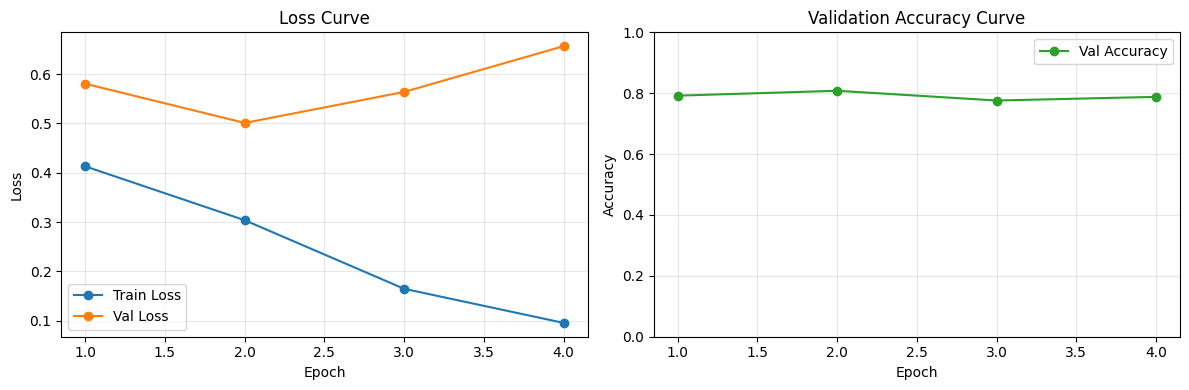

In [14]:
import matplotlib.pyplot as plt

if len(train_loss_history) == 0 or len(val_loss_history) == 0:
    print("No training history found. Run the fine-tuning cell first.")
else:
    epochs = range(1, len(train_loss_history) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, train_loss_history, marker='o', label='Train Loss')
    axes[0].plot(epochs, val_loss_history, marker='o', label='Val Loss')
    axes[0].set_title('Loss Curve')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(epochs, val_acc_history, marker='o', color='tab:green', label='Val Accuracy')
    axes[1].set_title('Validation Accuracy Curve')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_ylim(0, 1)
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

### B.3. Predict on the Test set

In [15]:
test_loader = DataLoader(test_tokenized, batch_size=8)

bert.eval()
all_logits = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Predicting"):
        inputs = {
            'input_ids': batch['input_ids'].to(device),
            'attention_mask': batch['attention_mask'].to(device)
        }
        outputs = bert(**inputs)
        all_logits.append(outputs.logits.cpu())

predictions = torch.cat(all_logits, dim=0).numpy()
test_preds = np.argmax(predictions, axis=-1)

Predicting: 100%|██████████| 32/32 [00:02<00:00, 13.56it/s]


In [16]:
if 'labels' in test_tokenized.column_names:
    y_true = np.array(test_tokenized['labels']).astype(int)
    y_pred = np.array(test_preds).astype(int)

    print(f"Test Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print(f"Test F1 (macro): {f1_score(y_true, y_pred, average='macro'):.4f}")
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, digits=4))
else:
    print("No 'labels' column found in test_tokenized. Metrics cannot be computed.")

Test Accuracy: 0.8600
Test F1 (macro): 0.7829

Classification report:
              precision    recall  f1-score   support

           0     0.6471    0.6600    0.6535        50
           1     0.9146    0.9100    0.9123       200

    accuracy                         0.8600       250
   macro avg     0.7808    0.7850    0.7829       250
weighted avg     0.8611    0.8600    0.8605       250

